In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except:
    ! pip install seaborn
    import seaborn as sns
from tqdm import tqdm

#### Functions

In [2]:
class ExploratoryDataAnalysis:
    def __init__(self, str_uri, str_target):
        self.str_uri = str_uri
        self.str_target = str_target
    def import_data(self):
        df = pd.read_csv(self.str_uri)
        # dates
        for col in tqdm(['origination_date','dob']):
            df[col] = pd.to_datetime(df[col], errors='coerce')
        # sort
        df.sort_values(by='origination_date', ascending=True, inplace=True)
        # replace terms w val 0
        df['term_months'] = df['term_months'].replace(0, np.nan)
        # clean channel
        df['channel'] = df['channel'].str.lower().str.strip()
        # clean state
        df['state'] = df['state'].str.lower().str.strip()
        # save to object
        self.df = df
    def get_df_info(self):
        int_nrows, int_ncols = self.df.shape
        dtm_min = self.df['origination_date'].min()
        dtm_max = self.df['origination_date'].max()
        flt_nan = self.df.isna().values.mean()
        print(f'Rows: {int_nrows}')
        print(f'Columns: {int_ncols}')
        print(f'Min Date: {dtm_min}')
        print(f'Max Date: {dtm_max}')
        print(f'Proportion NaN: {flt_nan:0.4f}')
        # save to object
        self.int_nrows = int_nrows
        self.int_ncols = int_ncols
        self.dtm_min = dtm_min
        self.dtm_max = dtm_max
        self.flt_nan = flt_nan
    def fe_for_eda(self):
        df_tmp = self.df.copy()
        # get age
        df_tmp['age'] = (pd.Timestamp.today() - df_tmp['dob']).dt.days // 365
        # get binary columns for each channel, state
        df_dummies = pd.get_dummies(df_tmp[['channel','state']], columns=['channel','state'], dtype=int)
        df = pd.concat([df_tmp, df_dummies], axis=1)
        # get the origination month
        df['origination_month'] = df['origination_date'].dt.to_period('M').dt.to_timestamp()
        # save to object
        self.df = df
    def descriptives(self):
        list_cols_no = ['loan_id','origination_date','dob','origination_month','channel','state']
        list_cols = [col for col in self.df.columns if col not in list_cols_no]
        # make df
        list_dict_row = []
        for col in tqdm(list_cols):
            flt_nan = self.df[col].isnull().mean()
            int_n_unique = self.df[col].nunique()
            flt_min = self.df[col].min()
            flt_max = self.df[col].max()
            flt_mn = self.df[col].mean()
            flt_sd = self.df[col].std()
            flt_mdn = self.df[col].median()
            dict_row = {
                'col': col,
                'nan': flt_nan,
                'nunique': int_n_unique,
                'min': flt_min,
                'max': flt_max,
                'mean': flt_mn,
                'std': flt_sd,
                'mdn': flt_mdn,
            }
            list_dict_row.append(dict_row)
        df_descriptives = pd.DataFrame(list_dict_row)
        # save to object
        self.df_descriptives = df_descriptives
    def plot_target_by_month(self):
        # copy
        df_tmp = self.df.copy()
        df_tmp['count'] = 1
        dict_agg = {
            self.str_target: 'mean',
            'count': 'sum',
        }
        df_pivot = df_tmp.groupby(by='origination_month', as_index=False).agg(dict_agg)
        
        # plot
        x = df_pivot['origination_month']
        y = df_pivot[self.str_target]
        y2 = df_pivot['count']
        int_n_months = len(x)
        int_n_total = y2.sum()
        flt_n_per_month = int_n_total / int_n_months
        # ax
        fig, ax = plt.subplots(figsize=(15,5))
        ax.set_title(f'{self.str_target} and N Funded by Origination Month (N Months = {int_n_months}; N Total = {int_n_total}; N per Month = {flt_n_per_month:0.2f})')
        ax.set_xlabel('Origination Month')
        ax.set_ylabel(self.str_target)
        # target
        ax.plot(x, y, label=self.str_target)
        # second y
        ax2 = ax.twinx()
        # count
        ax2.plot(x, y2, label='N Funded', linestyle='--', color='red')
        ax2.set_ylabel('N Funded')
        
        # show
        plt.show()
    def correlation_with_target(self):
        list_cols_no = ['loan_id','origination_date','dob',str_target,'charged_off_amount','paid_interest_amount','origination_month','channel','state']
        list_cols = [col for col in self.df.columns if col not in list_cols_no]
        dv = self.df[str_target]
        
        list_dict_row = []
        for col in list_cols:
            # iv
            iv = self.df[col]
            # make tmp df
            df_tmp = pd.DataFrame({
                'dv': dv,
                'iv': iv,
            })
            # drop na
            df_tmp.dropna(subset=['iv'], inplace=True)
            # get n unique
            int_n_unique = df_tmp['iv'].nunique()
            # logic
            if int_n_unique == 1:
                str_type = 'no_variance'
                flr_correlation = 0
            elif int_n_unique == 2:
                str_type = 'phi'
                flt_correlation = df_tmp['iv'].corr(df_tmp['dv'])
            elif int_n_unique > 2:
                str_type = 'point_biserial'
                flt_correlation = df_tmp['iv'].corr(df_tmp['dv'])
            else:
                pass
            # row
            dict_row = {
                'col': col,
                'type': str_type,
                'correlation': flt_correlation,
            }
            list_dict_row.append(dict_row)
        # make df
        df_corr = pd.DataFrame(list_dict_row)
        # get abs val
        df_corr['correlation_abs'] = df_corr['correlation'].abs()
        # sort
        df_corr.sort_values(by='correlation_abs', ascending=True, inplace=True)
        # save to object
        self.df_corr = df_corr
    def plot_correlation_with_target(self):
        # x,y
        x = self.df_corr['col']
        y = self.df_corr['correlation_abs']
        # ax
        fig, ax = plt.subplots(figsize=(7,9))
        ax.set_title(f'Correlation (Abs Value) with {str_target} by Column')
        ax.set_xlabel('Correlation (Abs Value)')
        # plot
        ax.barh(x, y)
        # show
        plt.show()
    def make_violin_plots(self):
        list_cols = [
            'loan_amount',
            'employment_length_years',
            'stated_income',
            'bureau_score',
            'open_trades',
            'utilization',
            'inquiries_6m',
        ]
        for col in list_cols:
            fig, ax = plt.subplots(figsize=(9,5))
            ax.set_title(f'Violin Plot of {col}')
            sns.violinplot(data=self.df, y=col, ax=ax)
            plt.show()

#### Constants

In [3]:
str_bucket = os.getcwd().split('/')[4].replace('_','-')
print(f'Bucket: {str_bucket}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_dirname_output = './output'

str_target = 'default_12m'

# data uri
str_filename = 'Data Science - installment_loans_data.csv'
str_uri = f's3://{str_bucket}/00_data_collection/{str_filename}'

Bucket: credit-risk-model-braviant
Task: 01_eda


#### Output

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Initialize EDA class

In [5]:
# init
cls_eda = ExploratoryDataAnalysis(
    str_uri=str_uri,
    str_target=str_target,
)

#### Import data

In [6]:
cls_eda.import_data()
cls_eda.df

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)
100%|██████████| 2/2 [00:00<00:00, 19.58it/s]


,loan_id,origination_date,dob,loan_amount,term_months,channel,employment_length_years,stated_income,state,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,default_12m,charged_off_amount,paid_interest_amount,apr
5891,17794,2022-01-01,1992-02-29,5410,18.0,partner,8.39,2951.0,wi,0,604.0,1.0,1.0,0.47,3.0,1,0,0.00,1715.89,0.221
13404,13499,2022-01-01,1966-05-05,10000,12.0,web,4.52,5410.0,fl,0,600.0,2.0,0.0,0.46,3.0,0,0,0.00,1672.59,0.209
11238,24476,2022-01-01,1985-02-06,8480,12.0,web,3.81,3244.0,tx,0,557.0,2.0,0.0,0.48,5.0,2,0,0.00,2379.19,0.303
5589,5438,2022-01-01,1981-11-06,3510,18.0,web,9.82,5147.0,il,1,651.0,3.0,0.0,0.18,1.0,0,0,0.00,706.84,0.150
1244,11493,2022-01-01,1991-11-27,6630,24.0,web,4.99,6389.0,tx,1,611.0,1.0,0.0,0.41,3.0,1,0,0.00,2160.10,0.159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15382,23591,2024-12-28,1975-12-12,6970,12.0,mobile,9.41,6511.0,wa,0,607.0,2.0,1.0,0.47,4.0,1,0,0.00,1147.42,0.200
9616,15828,2024-12-28,1984-11-26,8450,12.0,mobile,8.97,4278.0,tn,1,662.0,6.0,0.0,0.52,2.0,0,0,0.00,1163.61,0.160
7158,17304,2024-12-28,2003-07-07,970,24.0,web,4.01,3885.0,mo,0,595.0,2.0,0.0,0.34,0.0,0,0,0.00,287.05,0.166
22683,13374,2024-12-28,1975-12-01,5700,12.0,mobile,7.10,13121.0,ga,0,583.0,2.0,0.0,0.31,2.0,2,0,0.00,803.60,0.156


#### Data set info

In [7]:
cls_eda.get_df_info()

Rows: 25308
Columns: 20
Min Date: 2022-01-01 00:00:00
Max Date: 2024-12-28 00:00:00
Proportion NaN: 0.0066


#### FE for EDA

In [8]:
cls_eda.fe_for_eda()

#### Descriptives

In [9]:
cls_eda.descriptives()
cls_eda.df_descriptives

100%|██████████| 42/42 [00:00<00:00, 792.63it/s]


,col,nan,nunique,min,max,mean,std,mdn
0,loan_amount,0.000000,1037,700.00,49930.000,5465.570966,3124.847601,4890.000
1,term_months,0.003003,6,6.00,84.000,19.083386,9.602377,18.000
2,employment_length_years,0.026474,1632,-1.00,68.540,5.823461,6.760675,5.070
3,stated_income,0.017820,10118,111.00,100000.000,6015.823832,4588.827436,4965.000
4,has_prior_loans_with_us,0.000000,2,0.00,1.000,0.304094,0.460032,0.000
5,bureau_score,0.021456,322,300.00,900.000,629.714516,66.578428,630.000
6,open_trades,0.015213,14,0.00,17.000,2.207319,1.730472,2.000
7,delinq_12m,0.009997,7,0.00,6.000,0.365077,0.623303,0.000
8,utilization,0.009997,150,0.00,1.500,0.374428,0.211069,0.340
9,inquiries_6m,0.009444,12,0.00,11.000,1.883242,1.553925,2.000


#### Visualize target over time

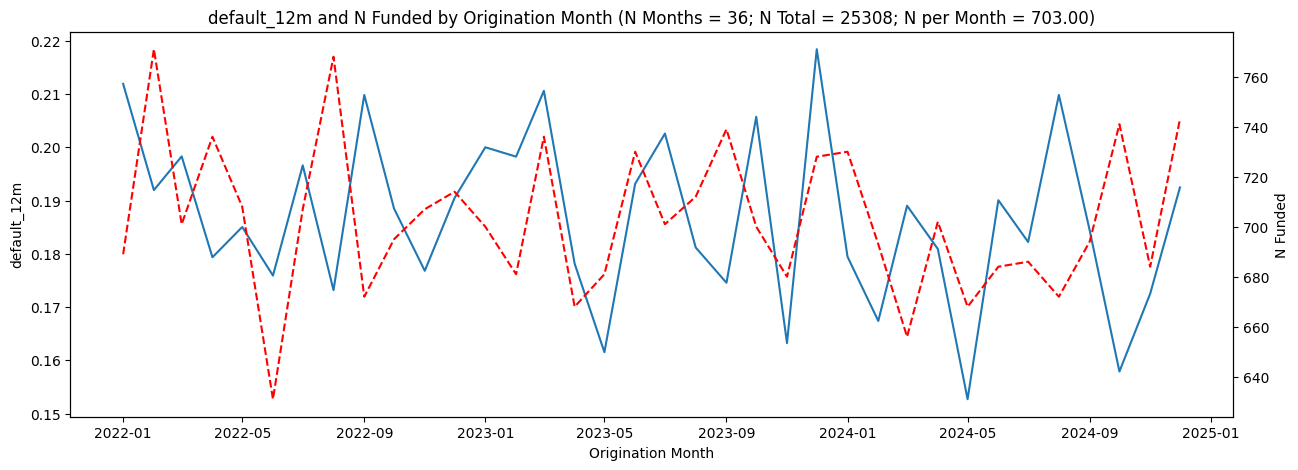

In [10]:
cls_eda.plot_target_by_month()

#### Get correlation with target

In [11]:
cls_eda.correlation_with_target()
cls_eda.df_corr

,col,type,correlation,correlation_abs
24,state_ma,phi,-0.000157,0.000157
17,state_??,phi,-0.000367,0.000367
12,age,point_biserial,0.000891,0.000891
21,state_ga,phi,0.001306,0.001306
22,state_il,phi,0.001515,0.001515
14,channel_partner,phi,-0.001602,0.001602
26,state_mi,phi,-0.001645,0.001645
23,state_in,phi,0.002236,0.002236
2,employment_length_years,point_biserial,-0.002248,0.002248
36,state_wa,phi,-0.002807,0.002807


#### Plot correlations with target

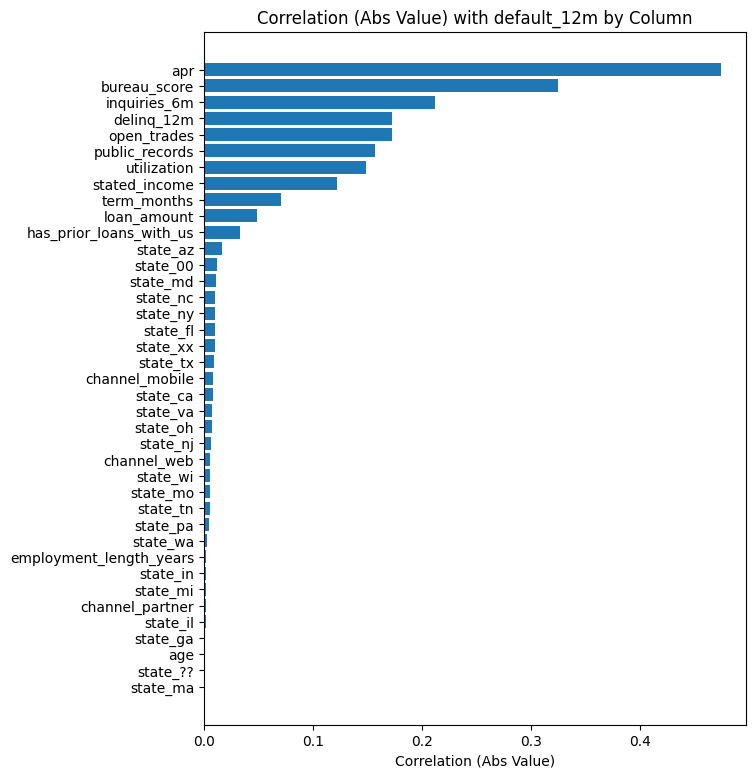

In [12]:
cls_eda.plot_correlation_with_target()

#### Violing Plots for distributions and outliers

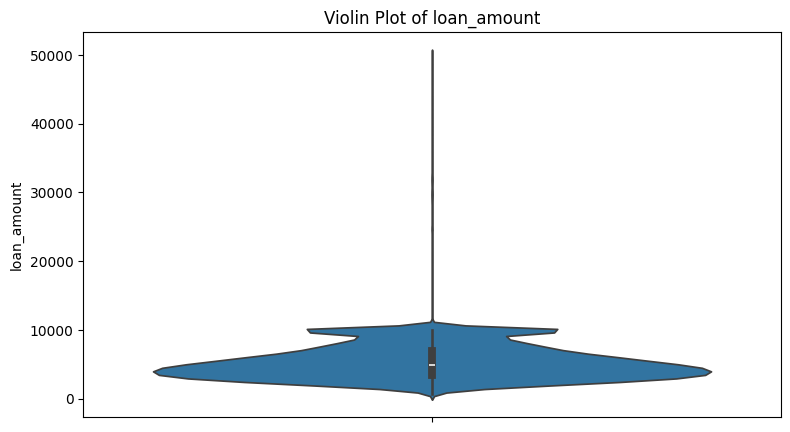

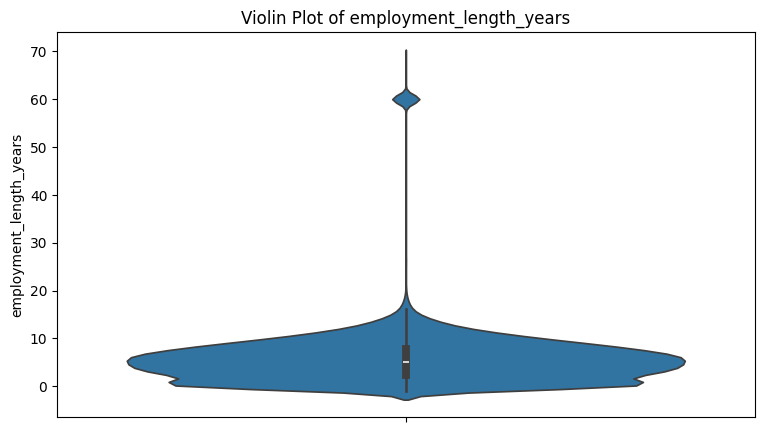

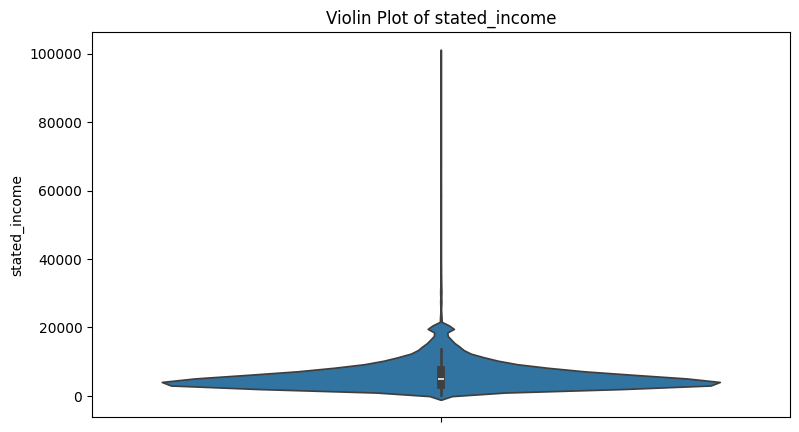

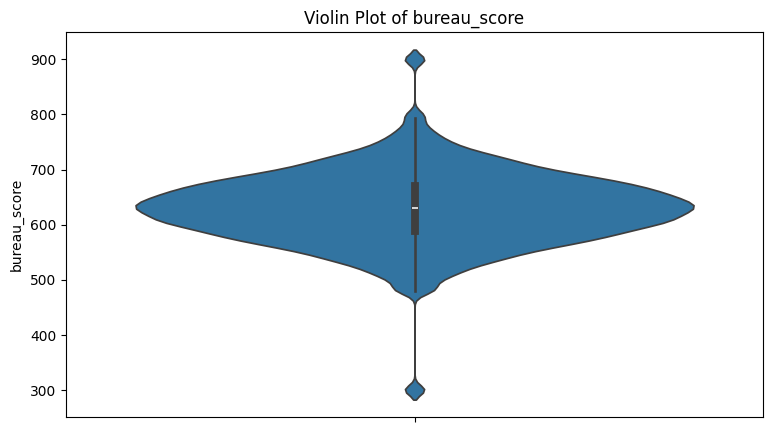

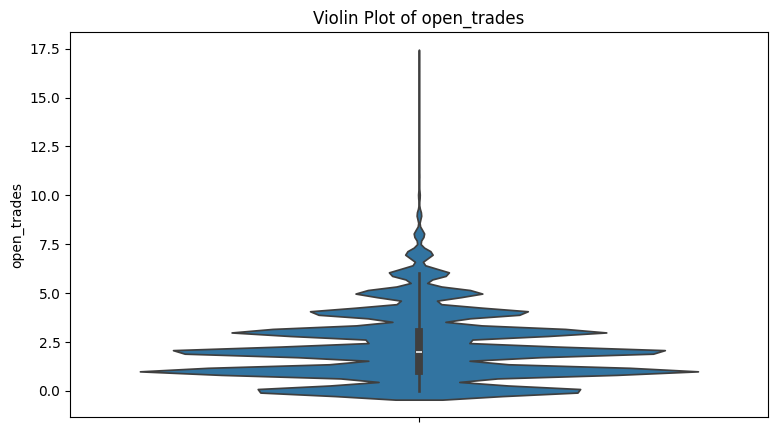

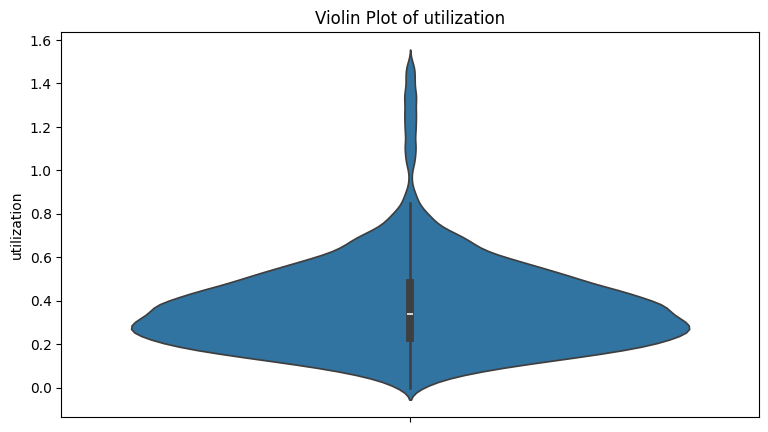

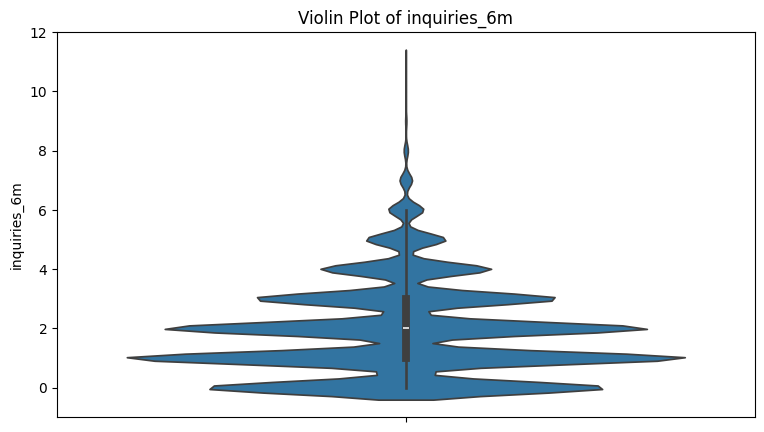

In [13]:
cls_eda.make_violin_plots()